# 3. Análise da operação: regimes associados ao consumo

**Pergunta:** existem regimes de comandos e estado do motor com distribuições de consumo diferentes?
**Tipo:** não supervisionado, exploração de todas as coletas. Não há separação treino/teste nesta descrição exploratória, nem alegação de previsão fora da amostra.

Cada observação resume uma janela completa de 30 s. O agrupamento principal usa comandos, rotação, torque e velocidade, **sem Taccm**. A alternativa usa `Pi_1`, `Pi_2`, `Pi_3` e `Pi_8`. Ambos excluem `Pi_6` e `Pi_13` para não embutir consumo/razão de torque na comparação Pi. Compararemos perfis, cobertura por ensaio e silhouette. Essa métrica mede separação geométrica, não validade física ou severidade.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
get_ipython().run_line_magic("matplotlib", "inline")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Motor/Dados/Data_set.CSV").is_file())
sys.path.insert(0, str(ROOT / "Motor/notebooks"))
from consumo_utils import load_data, forecast_frame, regressor
OUT = ROOT / "Motor/resultados_consumo/03_analise_operacao"
OUT.mkdir(parents=True, exist_ok=True)
dados = load_data(ROOT)
manifest = {
    "python": platform.python_version(), "pandas": pd.__version__,
    "numpy": np.__version__, "scikit_learn": sklearn.__version__,
    "seed": 42, "unidade": "U = unidade numérica de Taccm; unidade física não confirmada",
    "sha256": {name: hashlib.sha256((ROOT / "Motor/Dados" / name).read_bytes()).hexdigest()
               for name in ["Data_set.CSV", "Data_set_param.CSV", "Dataset_Modelagem_Pi.csv"]},
}
(OUT / "ambiente.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("Amostras por ensaio:", dados.groupby("Experimento").size().to_dict())
print("Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.")

Amostras por ensaio: {'D1T1A': 1984, 'D1T1B': 1776, 'D1T2': 3876, 'D2T1': 1703}
Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score, adjusted_rand_score
rows=[]
for experiment,g in dados.groupby("Experimento"):
    g=g.sort_values("Temp").reset_index(drop=True)
    assert g.Temp.diff().dropna().eq(1).all()
    for _,w in g.groupby(np.arange(len(g))//30):
        if len(w)!=30: continue
        row=dict(Experimento=experiment,Temp=w.Temp.iloc[0],fim=w.Temp.iloc[-1],
                 consumo_medio=w.Taccm.mean(),consumo_p95=w.Taccm.quantile(.95),
                 Velo_std=w.Velo.std(ddof=0),Tau_std=w.Tau.std(ddof=0),
                 freio_frac=(w.Brake>0).mean(),Gear_moda=w.Gear.mode().iloc[0])
        for c in ["Velo","Acc","Brake","n","Tau","Pi_1","Pi_2","Pi_3","Pi_8"]:
            row[c+"_media"]=w[c].mean()
        rows.append(row)
windows=pd.DataFrame(rows)
raw_features=[c+"_media" for c in ["Velo","Acc","Brake","n","Tau"]]+["Velo_std","Tau_std","freio_frac","Gear_moda"]
pi_features=[c+"_media" for c in ["Pi_1","Pi_2","Pi_3","Pi_8"]]
print("Janelas completas:", windows.groupby("Experimento").size().to_dict())

Janelas completas: {'D1T1A': 66, 'D1T1B': 59, 'D1T2': 129, 'D2T1': 56}


In [3]:
quality=[]; labels={}
for representation,columns in [("sensores",raw_features),("Pi",pi_features)]:
    prep=make_pipeline(SimpleImputer(strategy="median"),StandardScaler())
    X=prep.fit_transform(windows[columns])
    for k in [2,3,4,5]:
        km=KMeans(n_clusters=k,n_init=20,random_state=42)
        group=km.fit_predict(X)
        score=silhouette_score(X,group)
        quality.append(dict(representacao=representation,k=k,silhouette=score))
        labels[(representation,k)]=group
quality=pd.DataFrame(quality)
for representation in ["sensores","Pi"]:
    best=quality[quality.representacao==representation].sort_values("silhouette",ascending=False).iloc[0]
    windows['grupo_'+representation]=labels[(representation,int(best.k))]
quality.to_csv(OUT/"qualidade_grupos.csv",index=False)
windows.to_csv(OUT/"janelas.csv",index=False)
profiles=windows.groupby("grupo_sensores").agg(
    n=("consumo_medio","size"),consumo_medio=("consumo_medio","mean"),
    consumo_mediano=("consumo_medio","median"),Tau_medio=("Tau_media","mean"),
    Acc_medio=("Acc_media","mean"),Velo_medio=("Velo_media","mean"),freio_fracao=("freio_frac","mean"))
pi_profiles=windows.groupby("grupo_Pi")[pi_features+["consumo_medio","Tau_media"]].mean()
composition=pd.crosstab(windows.Experimento,windows.grupo_sensores,normalize="index")
pi_composition=pd.crosstab(windows.Experimento,windows.grupo_Pi,normalize="index")
profiles.to_csv(OUT/"perfis_sensores.csv")
pi_profiles.to_csv(OUT/"perfis_pi.csv")
composition.to_csv(OUT/"composicao_ensaios.csv")
pi_composition.to_csv(OUT/"composicao_ensaios_pi.csv")
display(quality.round(3));display(profiles.round(3));display(pi_profiles.round(3))
display(composition.round(3));display(pi_composition.round(3))
ari=adjusted_rand_score(windows.grupo_sensores,windows.grupo_Pi)
print("Concordância entre representações, ARI:", round(ari,3))

,representacao,k,silhouette
0,sensores,2,0.296
1,sensores,3,0.269
2,sensores,4,0.256
3,sensores,5,0.251
4,Pi,2,0.283
5,Pi,3,0.272
6,Pi,4,0.278
7,Pi,5,0.250


,n,consumo_medio,consumo_mediano,Tau_medio,Acc_medio,Velo_medio,freio_fracao
grupo_sensores,,,,,,,
0,151,4.370,3.097,205.086,11.506,11.281,0.569
1,159,15.648,15.307,503.644,42.674,34.068,0.260


,Pi_1_media,Pi_2_media,Pi_3_media,Pi_8_media,consumo_medio,Tau_media
grupo_Pi,,,,,,
0,44.020,16.447,3.361,0.815,16.669,531.143
1,16.766,30.642,1.618,0.821,5.927,246.000


grupo_sensores,0,1
Experimento,,
D1T1A,0.455,0.545
D1T1B,0.508,0.492
D1T2,0.566,0.434
D2T1,0.321,0.679


grupo_Pi,0,1
Experimento,,
D1T1A,0.318,0.682
D1T1B,0.390,0.610
D1T2,0.302,0.698
D2T1,0.696,0.304


Concordância entre representações, ARI: 0.54


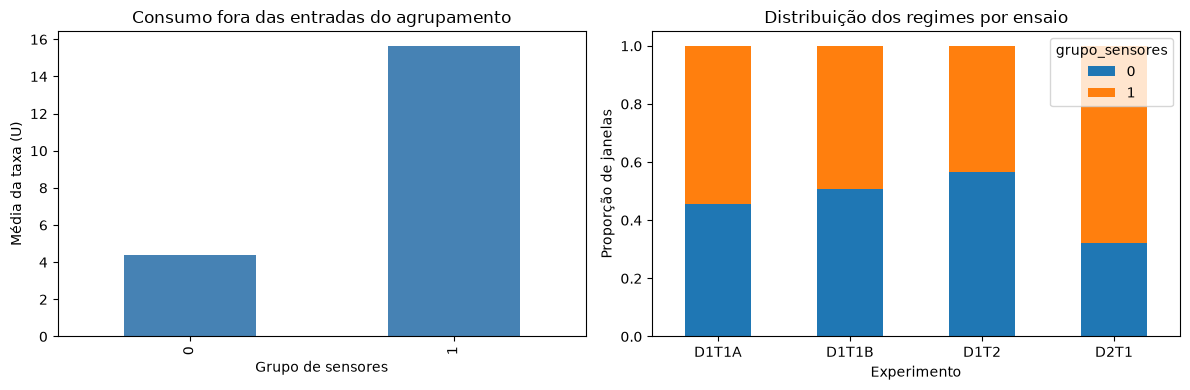

Os perfis dos grupos de sensores têm médias de consumo entre **4.37 e 15.65 U**. As relações são descritivas: não indicam que alterar um comando causará a diferença observada.

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
profiles.consumo_medio.plot.bar(ax=axes[0],color="steelblue")
axes[0].set(ylabel="Média da taxa (U)",xlabel="Grupo de sensores",title="Consumo fora das entradas do agrupamento")
composition.plot.bar(stacked=True,ax=axes[1])
axes[1].set(ylabel="Proporção de janelas",title="Distribuição dos regimes por ensaio")
axes[1].tick_params(axis="x",rotation=0)
fig.tight_layout();fig.savefig(OUT/"regimes_operacionais.png",dpi=150);plt.show()
lo=profiles.consumo_medio.min();hi=profiles.consumo_medio.max()
display(Markdown(f"Os perfis dos grupos de sensores têm médias de consumo entre **{lo:.2f} e {hi:.2f} U**. "
    "As relações são descritivas: não indicam que alterar um comando causará a diferença observada."))

## Limites e utilização

Os grupos são úteis para escolher trechos a investigar: alta demanda, baixa demanda e frenagem podem ter perfis diferentes. Nomes operacionais só devem ser atribuídos após inspeção temporal. Um grupo concentrado em um ensaio pode refletir clima, percurso ou sensor, não um regime geral. As leituras de freio até 102% exigem auditoria. O torque participou do agrupamento de sensores; portanto, diferenças de torque entre esses grupos não constituem evidência independente. Não existem falhas ou classes de severidade rotuladas aqui.